# 07 -- When your simulation is lying to you

**This is the part almost nobody teaches. It is the reason this repo exists.**

A learned potential is only valid within the distribution of its training data. Outside that distribution -- a configuration never seen during training -- it produces a number. It does not refuse. It does not warn. The number can be wildly wrong.

The danger is that a trajectory with wrong forces can still look perfectly normal: atoms move, energies fluctuate, temperature is stable. The simulation passes every naive sanity check and is physically nonsense.

This notebook teaches you how to catch it. The tools are:

1. **The force-gradient check** (from Notebook 01) -- the first thing you always run.
2. **Energy conservation** -- if total energy drifts, the forces or timestep are wrong.
3. **Committee models / uncertainty quantification** -- train an ensemble; when the members disagree, you are out-of-distribution.
4. **Distance to training set** -- flag configurations that are far from anything seen during training.

> **Prerequisites:** Notebooks 01-05.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from afs.md import (
    lj_energy, lj_forces, triangular_lattice,
    disk_cluster, thermal_velocities, run_md,
)

torch.manual_seed(0)
np.random.seed(0)

## 1. Manufacturing a lying simulation

First, let us deliberately create the failure mode. We will train a neural-network potential on configurations where all atoms are at least 1.0 apart (comfortable LJ distances), then run MD at high temperature until two atoms get very close -- a configuration the model has never seen.

The model will produce forces that are smooth and plausible-looking. The MD will run. The trajectory will look fine. But the physics is wrong.

In [2]:
# Train a simple MLP potential on a restricted range of distances
def pairwise_distances(pos):
    n = len(pos)
    return np.sort([np.linalg.norm(pos[i] - pos[j])
                    for i in range(n) for j in range(i+1, n)])

# Dataset: only safe configs (all pairs > 1.0). We draw perturbed lattices and
# keep the ones that stay in the comfortable range -- a small rejection sampler.
N_TRAIN   = 1000          # configs we actually train on
MAX_TRIES = 500_000       # safety cap so a bad filter can never hang the notebook
base = triangular_lattice(3, 3)
rng  = np.random.default_rng(42)
X_safe, Y_safe = [], []
print(f'Generating {N_TRAIN} safe training configs (rejection sampling, ~10s)...')
tries = 0
while len(Y_safe) < N_TRAIN and tries < MAX_TRIES:
    tries += 1
    pos = base + 0.18 * rng.standard_normal(base.shape)
    dists = pairwise_distances(pos)
    if dists.min() > 1.0 and abs(lj_energy(pos)) < 30:  # only safe configs
        X_safe.append(dists)
        Y_safe.append(lj_energy(pos))
if len(Y_safe) < N_TRAIN:
    raise RuntimeError(f'only {len(Y_safe)}/{N_TRAIN} safe configs in {MAX_TRIES} draws -- loosen the filter')
X_safe = np.array(X_safe); Y_safe = np.array(Y_safe)
print(f'Safe dataset: {len(Y_safe)} configs from {tries} draws, min dist in training: {X_safe.min():.3f}')

# Train
model_unsafe = nn.Sequential(
    nn.Linear(36, 64), nn.SiLU(),
    nn.Linear(64, 64), nn.SiLU(),
    nn.Linear(64, 1),
)
opt = torch.optim.Adam(model_unsafe.parameters(), lr=3e-3)
Xtr = torch.tensor(X_safe[:1000], dtype=torch.float32)
ytr = torch.tensor(Y_safe[:1000], dtype=torch.float32)
for _ in range(400):
    opt.zero_grad()
    loss = nn.functional.mse_loss(model_unsafe(Xtr).squeeze(), ytr)
    loss.backward(); opt.step()
print('Model trained on safe configs only.')

Generating 1000 safe training configs (rejection sampling, ~10s)...


Safe dataset: 1000 configs from 244184 draws, min dist in training: 1.000


Model trained on safe configs only.


In [3]:
# Run MD at high temperature -- atoms will eventually get too close
def nn_energy_unsafe(pos_np):
    feat = torch.tensor(pairwise_distances(pos_np), dtype=torch.float32).unsqueeze(0)
    model_unsafe.eval()
    with torch.no_grad():
        return model_unsafe(feat).item()

def nn_forces_unsafe(pos_np):
    pos = torch.tensor(pos_np, dtype=torch.float32, requires_grad=True)
    n = len(pos_np)
    dists = []
    for i in range(n):
        for j in range(i+1, n):
            diffs = pos[i] - pos[j]
            dists.append(torch.sqrt((diffs*diffs).sum()))
    feat = torch.stack(sorted(dists, key=lambda t: t.item())).unsqueeze(0)
    model_unsafe.eval()
    E = model_unsafe(feat)
    E.backward()
    return -pos.grad.numpy()

# High-temperature MD
start_pos = triangular_lattice(3, 3)
start_vel = thermal_velocities(9, d=2, temp=1.5, seed=99)  # very hot!

pos = start_pos.copy(); vel = start_vel.copy()
forces = nn_forces_unsafe(pos)
dt = 0.003

history_pos, history_min_dist, history_E, history_E_LJ = [], [], [], []
for step in range(600):
    # velocity-Verlet
    v_half = vel + 0.5 * forces * dt
    pos    = pos + v_half * dt
    forces = nn_forces_unsafe(pos)
    vel    = v_half + 0.5 * forces * dt

    min_d = pairwise_distances(pos).min()
    history_pos.append(pos.copy())
    history_min_dist.append(min_d)
    history_E.append(nn_energy_unsafe(pos) + 0.5 * np.sum(vel**2))
    history_E_LJ.append(lj_energy(pos) + 0.5 * np.sum(vel**2))

history_min_dist = np.array(history_min_dist)
print(f'Minimum pair distance reached: {history_min_dist.min():.3f}')
print(f'Training data minimum was:     {X_safe.min():.3f}')
ood_step = np.argmin(history_min_dist > 1.0)  # first step below training range
print(f'Out-of-distribution step:      {ood_step}')

Minimum pair distance reached: 0.177
Training data minimum was:     1.000
Out-of-distribution step:      14


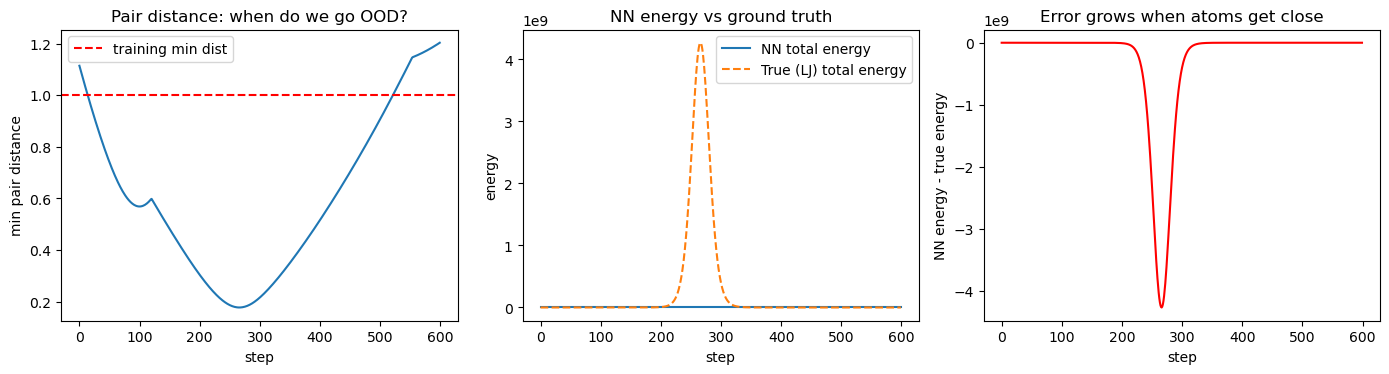

The NN energy looks plausible but diverges from the truth once min dist < training range.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
ax.plot(history_min_dist, lw=1.5)
ax.axhline(X_safe.min(), color='red', ls='--', label='training min dist')
ax.set_xlabel('step'); ax.set_ylabel('min pair distance')
ax.set_title('Pair distance: when do we go OOD?')
ax.legend()

ax = axes[1]
ax.plot(history_E,    label='NN total energy', lw=1.5)
ax.plot(history_E_LJ, label='True (LJ) total energy', lw=1.5, ls='--')
ax.set_xlabel('step'); ax.set_ylabel('energy')
ax.set_title('NN energy vs ground truth')
ax.legend()

ax = axes[2]
ax.plot(np.array(history_E) - np.array(history_E_LJ), color='red', lw=1.5)
ax.set_xlabel('step'); ax.set_ylabel('NN energy - true energy')
ax.set_title('Error grows when atoms get close')

plt.tight_layout(); plt.show()

print('The NN energy looks plausible but diverges from the truth once min dist < training range.')

## 2. Diagnostic 1: the force-gradient check

The force-gradient check (from Notebook 01) detects one specific failure: **the forces are not the gradient of the energy**. This happens if there is a bug in the force computation, or if the energy model is non-differentiable.

It does NOT catch wrong-but-smooth predictions. But it is fast, cheap, and should always be your first check.

In [5]:
def force_gradient_check(energy_fn, force_fn, pos, h=1e-4, atol=1e-2):
    """Check that force_fn == -d(energy_fn)/d(pos) at a given configuration."""
    analytic = force_fn(pos)
    numerical = np.zeros_like(pos)
    for i in range(pos.shape[0]):
        for k in range(pos.shape[1]):
            pp, pm = pos.copy(), pos.copy()
            pp[i, k] += h; pm[i, k] -= h
            numerical[i, k] = -(energy_fn(pp) - energy_fn(pm)) / (2 * h)
    max_err = np.max(np.abs(analytic - numerical))
    passed  = max_err < atol
    return passed, max_err

# Test at a safe configuration
pos_safe = triangular_lattice(3, 3) + 0.05 * np.random.randn(9, 2)
ok, err = force_gradient_check(nn_energy_unsafe, nn_forces_unsafe, pos_safe)
print(f'Force gradient check (safe config): passed={ok}, max_err={err:.6f}')

# Test at an unsafe configuration (atoms too close)
pos_ood = triangular_lattice(3, 3).copy()
pos_ood[0] = pos_ood[1] + np.array([0.3, 0.0])  # two atoms very close
ok2, err2 = force_gradient_check(nn_energy_unsafe, nn_forces_unsafe, pos_ood)
print(f'Force gradient check (OOD config):  passed={ok2}, max_err={err2:.6f}')
print()
print('Note: force-gradient check may STILL PASS even when energy is wrong.')
print('The forces can be wrong in absolute terms but still be -dE/dr.')

Force gradient check (safe config): passed=True, max_err=0.006948
Force gradient check (OOD config):  passed=False, max_err=0.603600

Note: force-gradient check may STILL PASS even when energy is wrong.
The forces can be wrong in absolute terms but still be -dE/dr.


## 3. Diagnostic 2: committee model uncertainty

The most practical uncertainty estimator for MLPs is a **committee** (ensemble): train $K$ identical networks with different random seeds. At prediction time, run all $K$ networks and compute the standard deviation of their predictions.

When the input is in-distribution, the members agree. When the input is out-of-distribution, they disagree -- they each extrapolate differently from the training data.

The standard deviation across committee members is a proxy for epistemic uncertainty: how much does the model not know?

Training committee of 5 models...


Committee trained.


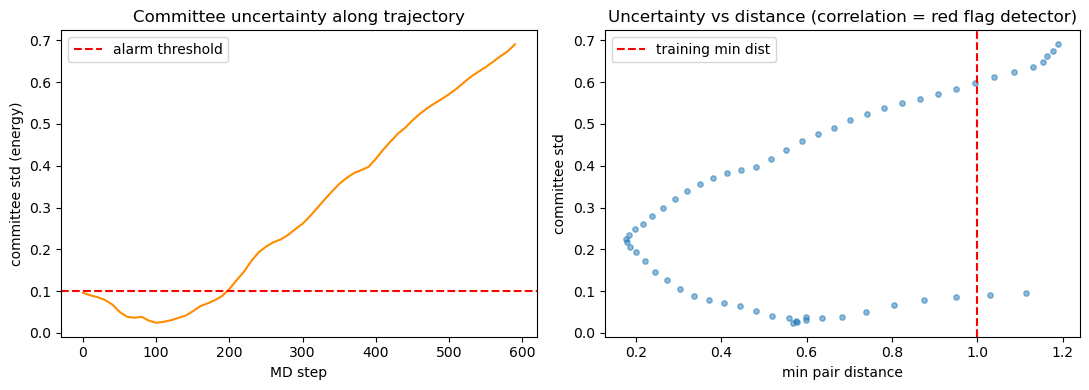

Max committee std: 0.6906
When std spikes, the model is in unknown territory.


In [6]:
# Train a committee of 5 models
def train_one(seed, Xtr, ytr, epochs=400):
    torch.manual_seed(seed)
    net = nn.Sequential(
        nn.Linear(36, 64), nn.SiLU(),
        nn.Linear(64, 64), nn.SiLU(),
        nn.Linear(64, 1),
    )
    opt = torch.optim.Adam(net.parameters(), lr=3e-3)
    for _ in range(epochs):
        opt.zero_grad()
        loss = nn.functional.mse_loss(net(Xtr).squeeze(), ytr)
        loss.backward(); opt.step()
    return net

print('Training committee of 5 models...')
committee = [train_one(s, Xtr, ytr) for s in range(5)]
print('Committee trained.')


def committee_predict(pos_np):
    """Return (mean_energy, std_energy) from committee."""
    feat = torch.tensor(pairwise_distances(pos_np), dtype=torch.float32).unsqueeze(0)
    preds = []
    for net in committee:
        net.eval()
        with torch.no_grad():
            preds.append(net(feat).item())
    return np.mean(preds), np.std(preds)


# Evaluate committee uncertainty along the MD trajectory
stds = []
for pos in history_pos[::10]:   # every 10th frame
    _, std = committee_predict(pos)
    stds.append(std)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

steps_sampled = np.arange(0, len(history_pos), 10)
ax = axes[0]
ax.plot(steps_sampled, stds, lw=1.5, color='darkorange')
ax.axhline(0.1, color='red', ls='--', label='alarm threshold')
ax.set_xlabel('MD step'); ax.set_ylabel('committee std (energy)')
ax.set_title('Committee uncertainty along trajectory')
ax.legend()

ax = axes[1]
ax.scatter(history_min_dist[::10], stds, alpha=0.5, s=15)
ax.axvline(X_safe.min(), color='red', ls='--', label='training min dist')
ax.set_xlabel('min pair distance'); ax.set_ylabel('committee std')
ax.set_title('Uncertainty vs distance (correlation = red flag detector)')
ax.legend()

plt.tight_layout(); plt.show()

print(f'Max committee std: {max(stds):.4f}')
print('When std spikes, the model is in unknown territory.')

## 4. Diagnostic 3: distance to training set

A complementary approach: measure how far the current configuration is from the nearest training example in feature space. If the distance is large, we are extrapolating.

This is simpler to implement than a committee but requires storing the training features. For a production system you would use an approximate nearest-neighbour search; here we use brute force.

Computing distances to training set (may take 30 s)...


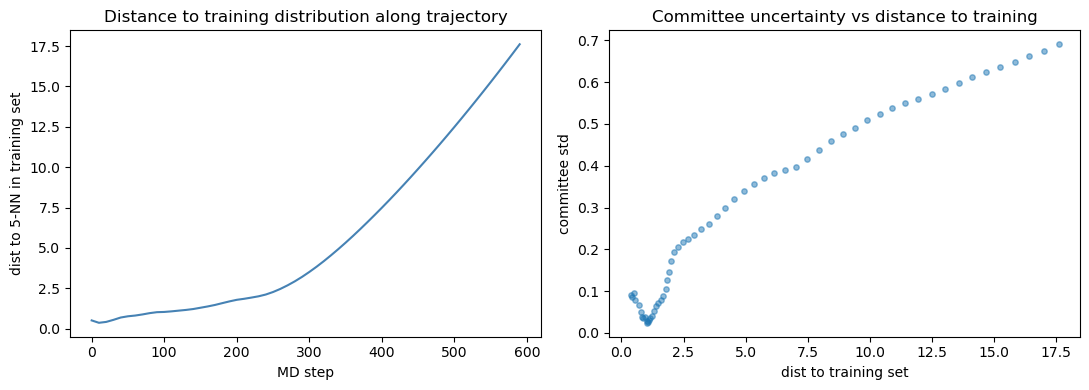

Correlation between distance-to-training and committee std: 0.970
High correlation confirms both signals detect the same OOD regime.


In [7]:
# Compute distance to training set for each trajectory frame
def dist_to_training(pos_np, X_train_feat, k=5):
    """Mean distance to the k nearest training examples in feature space."""
    feat = pairwise_distances(pos_np)
    diffs = X_train_feat - feat  # (n_train, n_feat)
    dists = np.linalg.norm(diffs, axis=1)  # (n_train,)
    return np.sort(dists)[:k].mean()


print('Computing distances to training set (may take 30 s)...')
d_to_train = [
    dist_to_training(pos, X_safe[:1000])
    for pos in history_pos[::10]
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(steps_sampled, d_to_train, lw=1.5, color='steelblue')
ax.set_xlabel('MD step'); ax.set_ylabel('dist to 5-NN in training set')
ax.set_title('Distance to training distribution along trajectory')

ax = axes[1]
ax.scatter(d_to_train, stds, alpha=0.5, s=15)
ax.set_xlabel('dist to training set'); ax.set_ylabel('committee std')
ax.set_title('Committee uncertainty vs distance to training')

plt.tight_layout(); plt.show()

corr = np.corrcoef(d_to_train, stds)[0, 1]
print(f'Correlation between distance-to-training and committee std: {corr:.3f}')
print('High correlation confirms both signals detect the same OOD regime.')

## 5. The OOD protocol: a practical checklist

Combining what we have learned, here is a minimal protocol for running a trustworthy ML-MD simulation:

**Before running:**
1. **Force-gradient check** on the starting configuration and a few random ones. If this fails, something is wrong with the force computation itself.

**During the run:**
2. **Monitor energy conservation.** If total energy drifts > ~1%, reduce the timestep or check for integration errors.
3. **Monitor committee uncertainty** (or distance to training set) every $N$ steps. If the uncertainty exceeds a threshold, stop and flag.

**After the run:**
4. **Retroactively plot uncertainty vs. time.** Spikes indicate frames to re-run with a more accurate method (DFT).
5. **If you find OOD frames, add them to the training set** (active learning) and retrain. Repeat until the uncertainty stays below the threshold.

This last loop -- run, flag, retrain -- is called **active learning** or **on-the-fly training**, and it is how modern foundation models are fine-tuned for specific applications.

In [8]:
# Simulate a run with on-the-fly stopping when uncertainty is too high
UNCERTAINTY_THRESHOLD = np.percentile(stds, 85)  # flag top 15% uncertain frames
print(f'Uncertainty threshold: {UNCERTAINTY_THRESHOLD:.4f}')

pos = start_pos.copy(); vel = start_vel.copy()
forces = nn_forces_unsafe(pos)
flagged_steps = []

for step in range(600):
    v_half = vel + 0.5 * forces * dt
    pos    = pos + v_half * dt
    forces = nn_forces_unsafe(pos)
    vel    = v_half + 0.5 * forces * dt

    # Check uncertainty every 20 steps (cheap)
    if step % 20 == 0:
        _, unc = committee_predict(pos)
        if unc > UNCERTAINTY_THRESHOLD:
            flagged_steps.append(step)

print(f'Flagged {len(flagged_steps)} checkpoints out of {600 // 20}')
print(f'First flag at step {flagged_steps[0] if flagged_steps else "never"}')
print()
print('In practice: flagged frames go to DFT; DFT results re-enter the training set.')

Uncertainty threshold: 0.5733


Flagged 4 checkpoints out of 30
First flag at step 520

In practice: flagged frames go to DFT; DFT results re-enter the training set.


## 6. Summary: trust but verify

The key lesson is that **a learned potential is only as trustworthy as its training distribution**. Outside that distribution it interpolates -- or rather extrapolates -- silently.

The three diagnostic tools:

| Diagnostic | What it catches | Cost |
|---|---|---|
| Force-gradient check | bugs in force computation | cheap |
| Energy conservation | wrong forces OR wrong timestep | free (already monitoring) |
| Committee uncertainty | out-of-distribution configurations | moderate (train K models) |
| Distance to training set | out-of-distribution configurations | cheap at inference |

None of these is perfect. But together they catch the vast majority of silent failures.

The good news: every tool in this notebook is physics, not magic. The force-gradient check is the same check you learned in Notebook 01. Energy conservation is the same check. The committee is just several copies of the model from Notebook 03. None of this requires a new framework or a special library.

### Exercises

1. **Calibrate the threshold.** Run many safe simulations and measure the committee uncertainty distribution. Set the threshold at the 95th percentile of in-distribution uncertainty. What fraction of OOD frames does this catch?

2. **Active learning toy.** Implement one round of active learning: (a) run MD until flagged, (b) compute the LJ energy at the flagged frame, (c) add it to the training set, (d) retrain, (e) run again. Does the model improve?

3. **Failure on MACE-MP.** MACE-MP is a universal model but still has out-of-distribution regions. Can you find one? Try very high-pressure configurations (atoms at 0.5 A apart) or exotic elements (actinides). Does the committee uncertainty (using MACE-MP with multiple random seeds) spike?